In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob as glb
from matplotlib.cm import get_cmap
from itertools import combinations

### Checking results

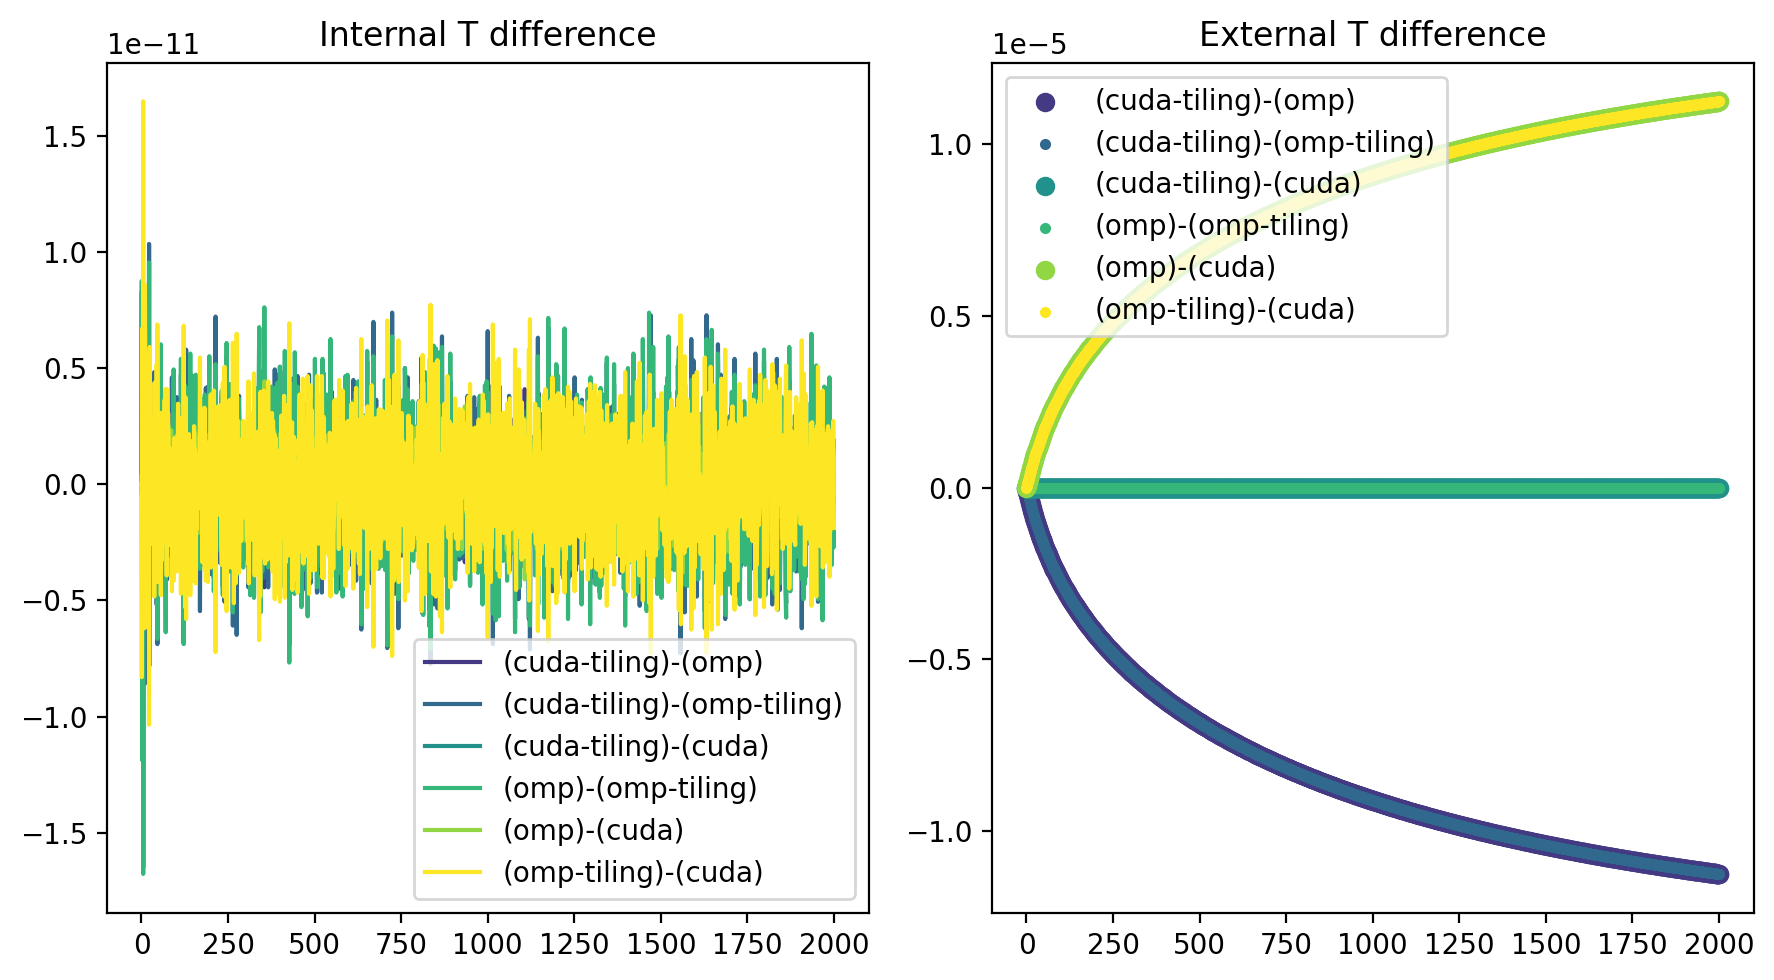

In [2]:
data_files = glb.glob("*.txt")
Nt = 2000
t_grid = np.arange(Nt+1)
Tin_dict = {df: None for df in data_files}
Tout_dict = {df: None for df in data_files}

for df in data_files:
    data = pd.read_csv(df, sep=" ")
    Tin_dict[df] = data["internal-T"].to_numpy()
    Tout_dict[df] = data["external-T"].to_numpy()

pairs = list(combinations(data_files, 2))
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(9, 5), dpi=200)
linestyle = ["o", "."]

cm = plt.get_cmap("viridis")
# plt.xlabel("Iteration")
# plt.ylabel(r"$\Delta T$")
for i, (df1, df2) in enumerate(pairs):
    clean_df1 = df1.split("-x")[0].replace("_avg_temp", "").replace("-n_threads4", "")
    clean_df2 = df2.split("-x")[0].replace("_avg_temp", "").replace("-n_threads4", "")

    ax1.plot(t_grid, Tin_dict[df1]-Tin_dict[df2], label=f"({clean_df1})-({clean_df2})", c=cm((i+1)/len(pairs)))
    ax1.set_title("Internal T difference")
    ax1.legend()

    ax2.scatter(
        t_grid, Tout_dict[df1]-Tout_dict[df2], 
        label=f"({clean_df1})-({clean_df2})", 
        marker=linestyle[i%len(linestyle)], 
        color=cm((i+1)/len(pairs))
        )
    ax2.set_title("External T difference")
    ax2.legend()

plt.tight_layout()

### Plotting temperatures

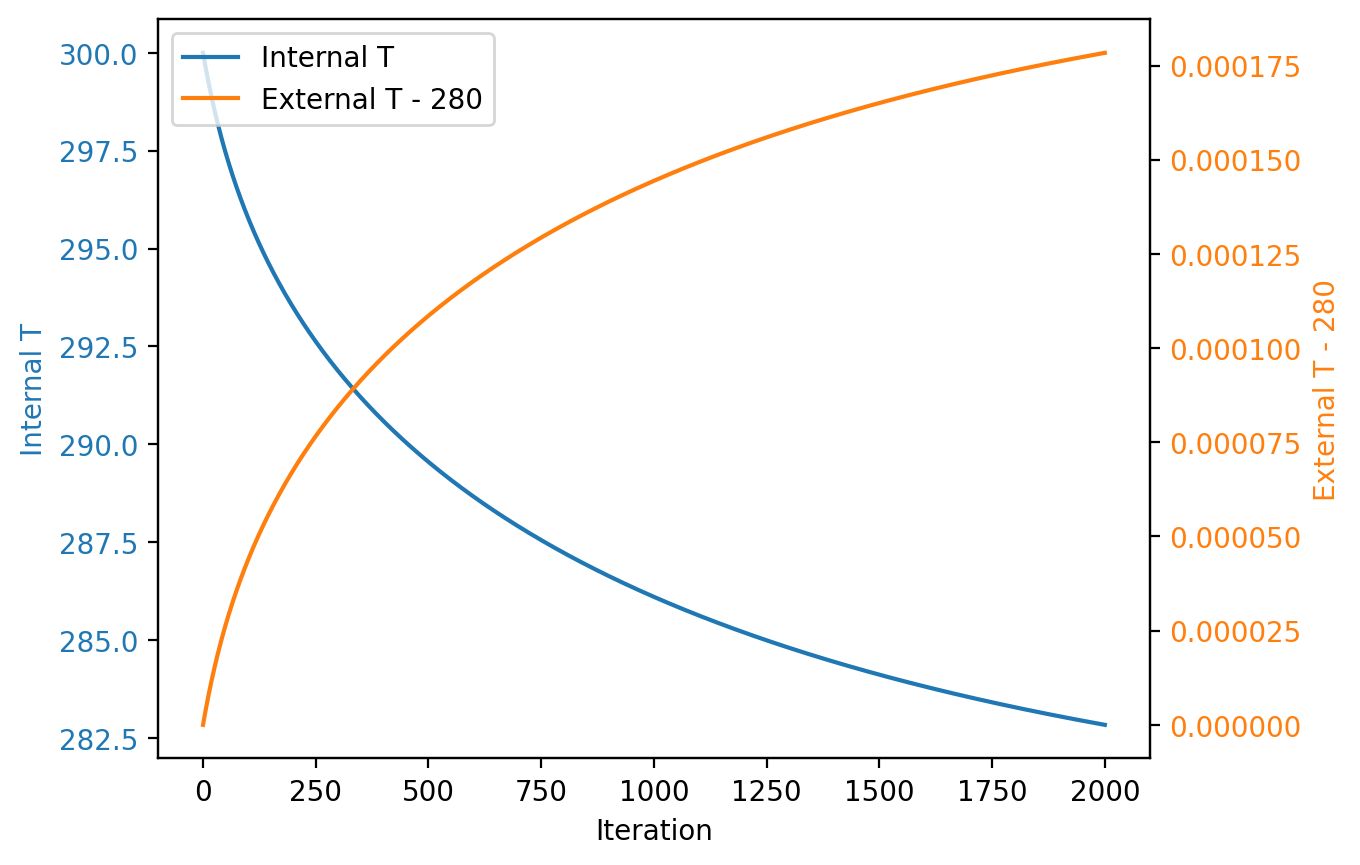

In [3]:
cuda_file = glb.glob("cuda*")[0]
# Crea la figura e il primo asse (sinistra)
fig, ax1 = plt.subplots(dpi=200)

# Primo plot sull'asse sinistro
line1 = ax1.plot(
    data["iteration"], data["internal-T"], color="tab:blue", label="Internal T"
)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Internal T", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Crea il secondo asse che condivide l'asse x (destra)
ax2 = ax1.twinx()

# Secondo plot sull'asse destro
T = 280
line2 = ax2.plot(
    data["iteration"],
    data["external-T"] - T,
    color="tab:orange",
    label=f"External T - {T}",
)
ax2.set_ylabel("External T - 280", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Legenda unica che unisce entrambe le curve
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.show()

### Benchmarking OMP routine

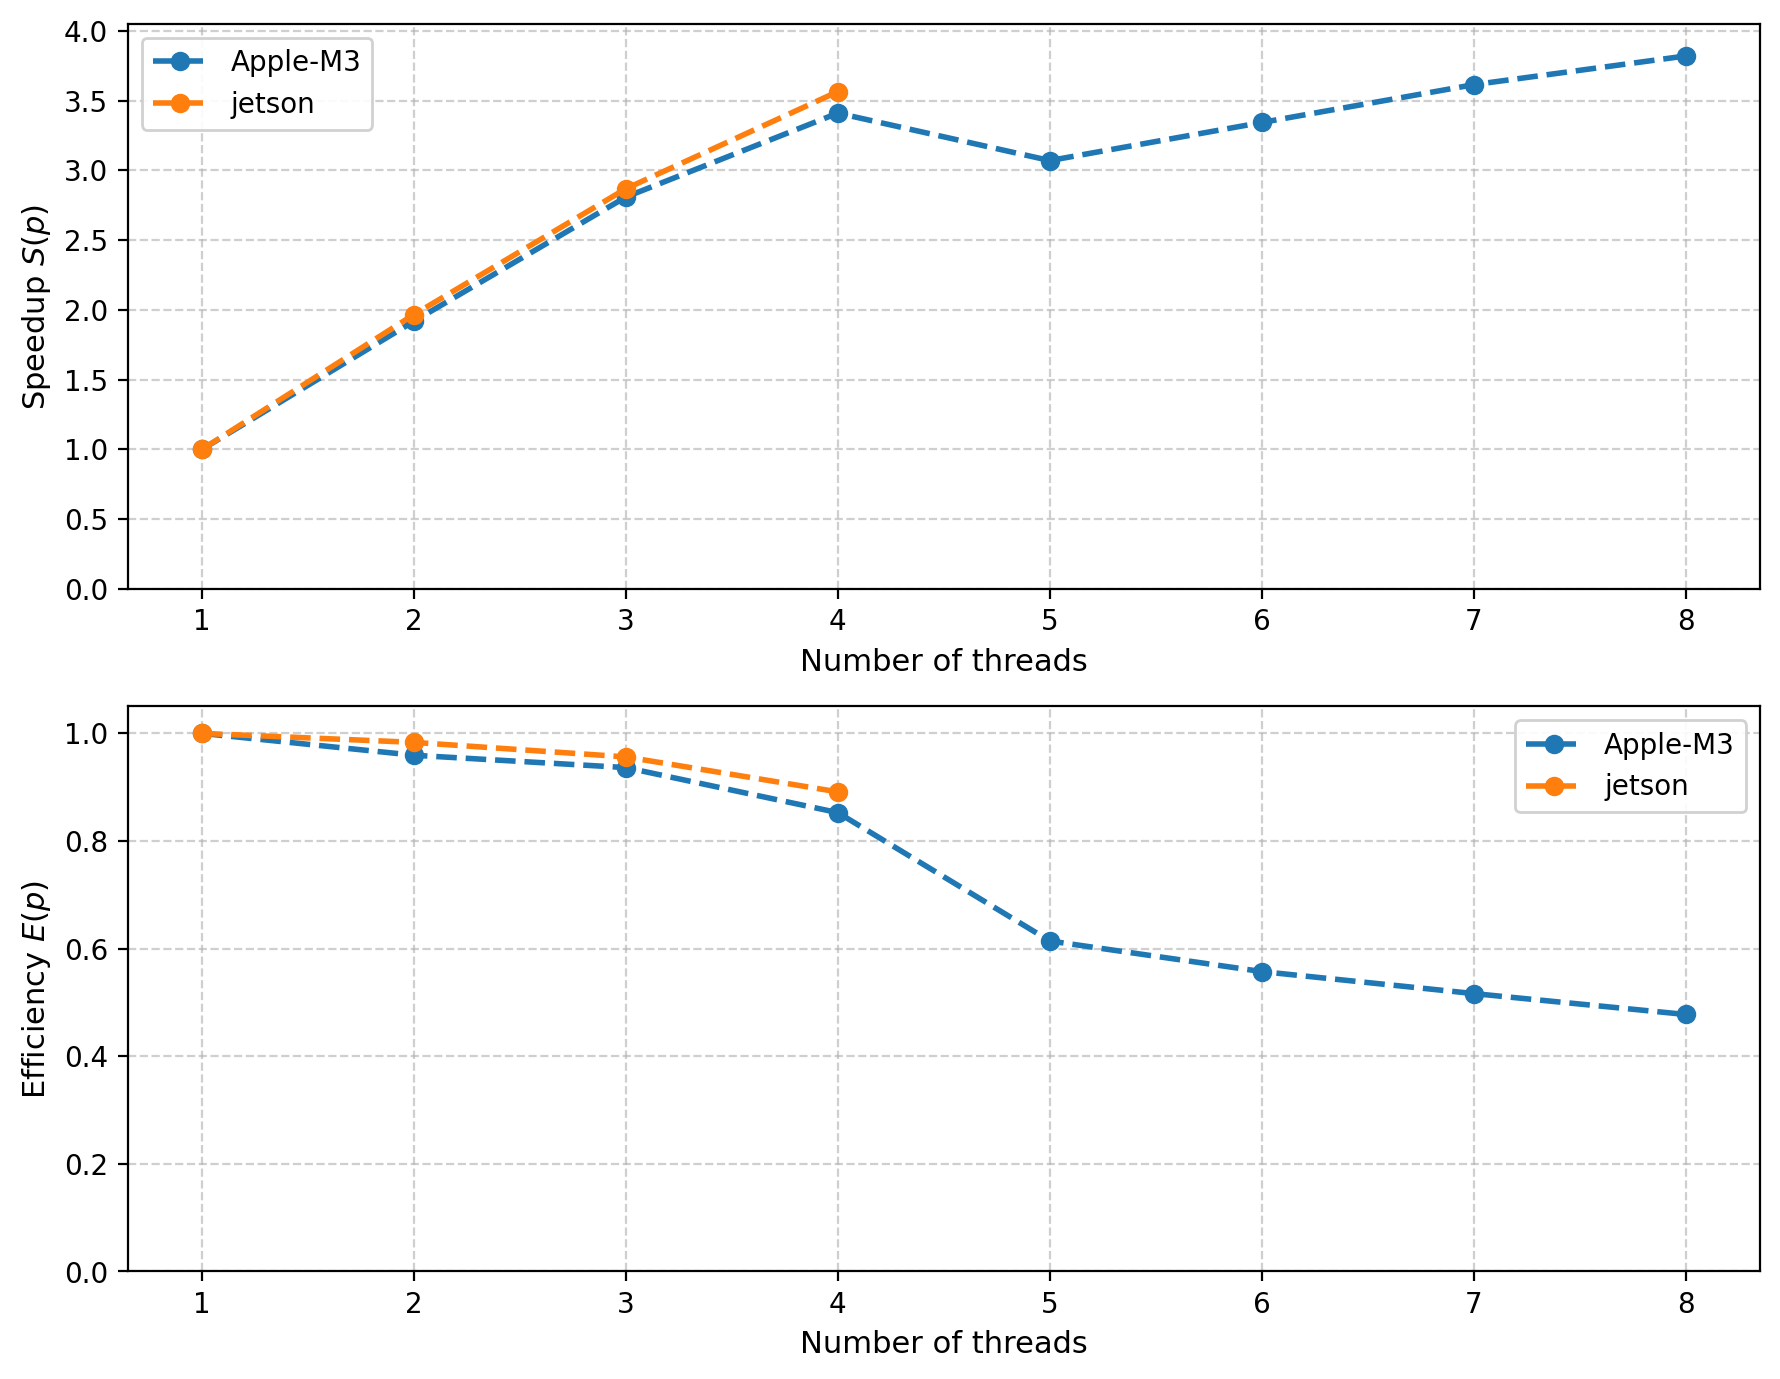

In [34]:
def nice_plot(axis, x, y, label, ls):
    axis.grid(True, linestyle="--", alpha=0.6)
    axis.plot(x, y, label=label, linestyle=ls, marker="o", linewidth=2, markersize=6)
    axis.set_xlabel("Number of threads", fontsize=11)


directories = glb.glob("thread-scaling-*")
n_threads = [4, 8]
wall_time_jet = np.zeros(n_threads[0])
wall_time_mac = np.zeros(n_threads[1])

for dir in directories:
    data_files = sorted(glb.glob(dir+"/*"))
    for i, df in enumerate(data_files):
        data = pd.read_csv(df, sep=" ")

        if dir.split("thread-scaling-")[1] == "mac":
            wall_time_mac[i] = data["elapsed-time"].iloc[-1]
        else:
            wall_time_jet[i] = data["elapsed-time"].iloc[-1]

fig, axes = plt.subplots(nrows=2, figsize=(9,7), dpi=200)
wall_time = [wall_time_mac, wall_time_jet]
for name, n_thr, wt in zip(("Apple-M3", "jetson"), (8, 4), wall_time):
    # Plot 1: speedup
    speedup = wt[0]/wt
    thr_num = np.arange(n_thr)+1
    nice_plot(axes[0], thr_num, speedup, f"{name}", "--")

    # Plot 2: efficiency
    efficiency = speedup/thr_num
    nice_plot(axes[1], thr_num, efficiency, f"{name}", "--")

axes[0].set_ylabel("Speedup $S(p)$", fontsize=11)
axes[0].set_ylim(0, 4.05)
axes[0].legend(frameon=True, facecolor="white", framealpha=0.9)

axes[1].set_ylabel("Efficiency $E(p)$", fontsize=11)
axes[1].set_ylim(0, 1.05)  # L'efficienza teorica sta tra 0 e 1
axes[1].legend(frameon=True, facecolor="white", framealpha=0.9)

axes[0].set_xticks(np.arange(1, 9))
axes[1].set_xticks(np.arange(1, 9))

plt.tight_layout()
